In [2]:
# 01. OTIMIZAÇÃO DE HIPERPARÂMETROS E MODELOS (GRID SEARCH LOOCV)

import pandas as pd
import numpy as np
import os
import time
from itertools import product
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings

warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("Iniciando Batalha de Modelos: Grid Search + LOOCV")
print("="*80)

# 1. Carregamento e Preparação dos Dados
DIR_REPORTS = '../reports/'

ARQUIVO_MATRIZ_ORIGINAL = 'tabela_features_eeg_completa.csv' 

caminho_arquivo = os.path.join(DIR_REPORTS, ARQUIVO_MATRIZ_ORIGINAL)

if not os.path.exists(caminho_arquivo):
    raise FileNotFoundError(f"Arquivo não encontrado: {arquivo}.")

df = pd.read_csv(caminho_arquivo)

# Lógica para preparar a matriz (caso tenha Condicao ou já esteja pronta)
if 'Condicao' in df.columns:
    df = df[df['Condicao'] == 'Face Feliz'].copy()

# Remove colunas de metadados (isolar as numéricas)
colunas_ignoradas = ['ID', 'Grupo', 'Condicao', 'Tipo', 'Frame_Num', 'Target']
features_numericas = [c for c in df.columns if c not in colunas_ignoradas]

# Agrupa por paciente (tirando a média) caso existam múltiplas linhas por ID
if 'ID' in df.columns and df['ID'].duplicated().any():
    df_agrupado = df.groupby(['ID', 'Grupo'])[features_numericas].mean().reset_index()
else:
    df_agrupado = df.copy()

# Configuração do Target (Alvo)
if 'Target' not in df_agrupado.columns:
    df_agrupado['Target'] = df_agrupado['Grupo'].map({'TEA': 1, 'Control': 0})

X = df_agrupado[features_numericas].values
y = df_agrupado['Target'].values

# Cálculo do peso para desbalanceamento (XGBoost)
n_controles = len(df_agrupado[df_agrupado['Target'] == 0])
n_tea = len(df_agrupado[df_agrupado['Target'] == 1])
peso_classes = n_controles / n_tea if n_tea > 0 else 1.0

# 2. Definição da Grade de Busca
k_valores = [5, 8, 10, 12, 15, 18, 20]
profundidades = [3, 4]
estimadores = [50, 100, 150, 200]
modelos = ['XGBoost', 'RandomForest']

todas_combinacoes = list(product(modelos, k_valores, profundidades, estimadores))
total_comb = len(todas_combinacoes)

print(f"Dataset carregado e validado: {len(X)} pacientes.")
print(f"Iniciando {total_comb} cenários. Isso equivale a {total_comb * len(X)} treinamentos...")
print("Por favor, aguarde. O loop está em execução...\n")

resultados = []
loo = LeaveOneOut()
tempo_inicio = time.time()

# 3. O Loop
for idx, (nome_modelo, k, depth, est) in enumerate(todas_combinacoes, 1):
    previsoes = []
    valores_reais = []
    
    for train_index, test_index in loo.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # Escalonamento
        scaler = RobustScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Seleção Dinâmica de Variáveis
        # Trava de segurança: k não pode ser maior que o número de variáveis disponíveis
        k_real = min(k, X_train_scaled.shape[1]) 
        selector = SelectKBest(score_func=f_classif, k=k_real)
        X_train_sel = selector.fit_transform(X_train_scaled, y_train)
        X_test_sel = selector.transform(X_test_scaled)
        
        # Configuração do Motor
        if nome_modelo == 'XGBoost':
            modelo = XGBClassifier(n_estimators=est, max_depth=depth, scale_pos_weight=peso_classes, 
                                   eval_metric='logloss', random_state=97, n_jobs=-1)
        else: # Random Forest
            modelo = RandomForestClassifier(n_estimators=est, max_depth=depth, class_weight='balanced', 
                                            random_state=97, n_jobs=-1)
            
        modelo.fit(X_train_sel, y_train)
        y_pred = modelo.predict(X_test_sel)
        
        previsoes.extend(y_pred)
        valores_reais.extend(y_test)
        
    # Acurácia do cenário atual
    acc = accuracy_score(valores_reais, previsoes)
    resultados.append({
        'Modelo': nome_modelo,
        'K_Features': k_real,
        'Profundidade': depth,
        'Estimadores': est,
        'Acurácia': acc
    })
    
    # Print de progresso a cada 20 cenários
    if idx % 20 == 0 or idx == total_comb:
        print(f"[{idx}/{total_comb}] Cenários concluídos...")

# 4. Avaliação e Ranking Final
df_resultados = pd.DataFrame(resultados)
df_ranking = df_resultados.sort_values(by=['Acurácia', 'Estimadores'], ascending=[False, True]).reset_index(drop=True)

tempo_total = (time.time() - tempo_inicio) / 60

print("\n" + "="*80)
print(f"Busca finalizada com sucesso em {tempo_total:.1f} minutos!")
print("="*80)
print("\n🏆 [TOP 10 MELHORES COMBINAÇÕES] 🏆\n")
print(df_ranking.head(10).to_string(index=False))

caminho_csv = os.path.join(DIR_REPORTS, 'grid_search_resultados_completos.csv')
df_ranking.to_csv(caminho_csv, index=False)
print(f"\nTabela completa com as {total_comb} combinações salva em: {caminho_csv}")
print("="*80)


Iniciando Batalha de Modelos: Grid Search + LOOCV
Dataset carregado e validado: 42 pacientes.
Iniciando 112 cenários. Isso equivale a 4704 treinamentos...
Por favor, aguarde. O loop está em execução...

[20/112] Cenários concluídos...
[40/112] Cenários concluídos...
[60/112] Cenários concluídos...
[80/112] Cenários concluídos...
[100/112] Cenários concluídos...
[112/112] Cenários concluídos...

Busca finalizada com sucesso em 9.6 minutos!

🏆 [TOP 10 MELHORES COMBINAÇÕES] 🏆

      Modelo  K_Features  Profundidade  Estimadores  Acurácia
     XGBoost           5             3          100  0.833333
     XGBoost           8             3           50  0.809524
     XGBoost           8             4           50  0.809524
RandomForest          10             3           50  0.809524
RandomForest          12             3           50  0.809524
RandomForest          12             4           50  0.809524
RandomForest          15             3           50  0.809524
RandomForest          15

In [3]:
# 02. IDENTIFICAÇÃO DAS 5 VARIÁVEIS (K=5)

import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif

print("\n" + "="*80)
print("Extraindo as 5 variáveis do modelo")
print("="*80)

DIR_REPORTS = '../reports/'

ARQUIVO_MATRIZ_ORIGINAL = 'tabela_features_eeg_completa.csv' 

caminho_arquivo = os.path.join(DIR_REPORTS, ARQUIVO_MATRIZ_ORIGINAL)
df = pd.read_csv(caminho_arquivo)

# Preparação 
if 'Condicao' in df.columns:
    df = df[df['Condicao'] == 'Face Feliz'].copy()

colunas_ignoradas = ['ID', 'Grupo', 'Condicao', 'Tipo', 'Frame_Num', 'Target']
features_numericas = [c for c in df.columns if c not in colunas_ignoradas]

if 'ID' in df.columns and df['ID'].duplicated().any():
    df_agrupado = df.groupby(['ID', 'Grupo'])[features_numericas].mean().reset_index()
else:
    df_agrupado = df.copy()

if 'Target' not in df_agrupado.columns:
    df_agrupado['Target'] = df_agrupado['Grupo'].map({'TEA': 1, 'Control': 0})

X = df_agrupado[features_numericas].values
y = df_agrupado['Target'].values

# 1. Escalonamento (igual ao Grid Search)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# 2. Seleção das 5 melhores variáveis
selector = SelectKBest(score_func=f_classif, k=5)
selector.fit(X_scaled, y)

# 3. Mapeamento dos nomes e pontuações
mascara_selecionadas = selector.get_support()
variaveis_top5 = np.array(features_numericas)[mascara_selecionadas]
pontuacoes_anova = selector.scores_[mascara_selecionadas]
p_valores = selector.pvalues_[mascara_selecionadas]

# 4. Exibição do Ranking
df_top5 = pd.DataFrame({
    'Feature (Região/Banda)': variaveis_top5,
    'F-Score (Força de Separação)': pontuacoes_anova,
    'P-Valor': p_valores
})

# Ordenando da mais forte para a menos forte
df_top5 = df_top5.sort_values(by='F-Score (Força de Separação)', ascending=False).reset_index(drop=True)

print("\nAs 5 variáveis c/ 83% de acc foram:\n")
print(df_top5.to_string())
print("\n" + "="*80)


Extraindo as 5 variáveis do modelo

As 5 variáveis c/ 83% de acc foram:

  Feature (Região/Banda)  F-Score (Força de Separação)   P-Valor
0            AlphaRel_P3                     12.919824  0.000882
1           AlphaRel_Fp2                     12.717112  0.000957
2             BetaRel_F7                     11.892270  0.001341
3            AlphaRel_F8                     11.464412  0.001602
4            GammaRel_F7                     10.217717  0.002717



In [5]:
# 03. LAZYCLASSIFIER

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Importando o LazyPredict
from lazypredict.Supervised import LazyClassifier

print("\n" + "="*80)
print("Iniciando radar de algoritmos (LazyClassifier) com as 5 features")
print("="*80)

DIR_REPORTS = '../reports/'

ARQUIVO_MATRIZ_ORIGINAL = 'tabela_features_eeg_completa.csv' 

caminho_arquivo = os.path.join(DIR_REPORTS, ARQUIVO_MATRIZ_ORIGINAL)
df = pd.read_csv(caminho_arquivo)

if 'Condicao' in df.columns:
    df = df[df['Condicao'] == 'Face Feliz'].copy()

colunas_ignoradas = ['ID', 'Grupo', 'Condicao', 'Tipo', 'Frame_Num', 'Target']
features_numericas = [c for c in df.columns if c not in colunas_ignoradas]

if 'ID' in df.columns and df['ID'].duplicated().any():
    df_agrupado = df.groupby(['ID', 'Grupo'])[features_numericas].mean().reset_index()
else:
    df_agrupado = df.copy()

if 'Target' not in df_agrupado.columns:
    df_agrupado['Target'] = df_agrupado['Grupo'].map({'TEA': 1, 'Control': 0})

# Isolando apenas as 5 variáveis mapeadas anteriormente
features_ouro = ['AlphaRel_P3', 'AlphaRel_Fp2', 'BetaRel_F7', 'AlphaRel_F8', 'GammaRel_F7']

# Verificação de segurança
for feature in features_ouro:
    if feature not in df_agrupado.columns:
        raise ValueError(f"A feature {feature} não foi encontrada na matriz.")

X = df_agrupado[features_ouro].values
y = df_agrupado['Target'].values

# Criando a divisão de Treino e Teste (Stratified para manter a proporção TEA/Controle)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=97, stratify=y)

print(f"Treinando com {len(X_train)} pacientes, Testando com {len(X_test)} pacientes.")
print("Iniciando varredura...\n")

# Instanciando e rodando o LazyClassifier
# O LazyClassifier já faz o escalonamento (StandardScaler) internamente
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None, random_state=97)
modelos, predicoes = clf.fit(X_train, X_test, y_train, y_test)

print("\n RANKING DO LAZYCLASSIFIER \n")
print(modelos.head(15).to_string())
print("\n" + "="*80)


Iniciando radar de algoritmos (LazyClassifier) com as 5 features
Treinando com 29 pacientes, Testando com 13 pacientes.
Iniciando varredura...


 RANKING DO LAZYCLASSIFIER 

                             Accuracy  Balanced Accuracy   ROC AUC  F1 Score  Precision    Recall  Time Taken
Model                                                                                                        
AdaBoostClassifier           0.846154           0.845238  0.857143  0.846154   0.846154  0.846154    0.096407
NearestCentroid              0.846154           0.845238  0.845238  0.846154   0.846154  0.846154    0.013552
Perceptron                   0.846154           0.845238  0.857143  0.846154   0.846154  0.846154    0.016494
GaussianNB                   0.846154           0.833333  0.833333  0.840385   0.880342  0.846154    0.013982
ExtraTreeClassifier          0.846154           0.833333  0.833333  0.840385   0.880342  0.846154    0.016082
RidgeClassifier              0.846154           0.83333

In [6]:
# 04. LAZYCLASSIFIER (seed)

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Importando o LazyPredict
from lazypredict.Supervised import LazyClassifier

print("\n" + "="*80)
print("Iniciando radar de algoritmos (LazyClassifier) com as 5 features")
print("="*80)

DIR_REPORTS = '../reports/'

ARQUIVO_MATRIZ_ORIGINAL = 'tabela_features_eeg_completa.csv' 

caminho_arquivo = os.path.join(DIR_REPORTS, ARQUIVO_MATRIZ_ORIGINAL)
df = pd.read_csv(caminho_arquivo)

if 'Condicao' in df.columns:
    df = df[df['Condicao'] == 'Face Feliz'].copy()

colunas_ignoradas = ['ID', 'Grupo', 'Condicao', 'Tipo', 'Frame_Num', 'Target']
features_numericas = [c for c in df.columns if c not in colunas_ignoradas]

if 'ID' in df.columns and df['ID'].duplicated().any():
    df_agrupado = df.groupby(['ID', 'Grupo'])[features_numericas].mean().reset_index()
else:
    df_agrupado = df.copy()

if 'Target' not in df_agrupado.columns:
    df_agrupado['Target'] = df_agrupado['Grupo'].map({'TEA': 1, 'Control': 0})

# Isolando apenas as 5 variáveis mapeadas anteriormente
features_ouro = ['AlphaRel_P3', 'AlphaRel_Fp2', 'BetaRel_F7', 'AlphaRel_F8', 'GammaRel_F7']

# Verificação de segurança
for feature in features_ouro:
    if feature not in df_agrupado.columns:
        raise ValueError(f"A feature {feature} não foi encontrada na matriz.")

X = df_agrupado[features_ouro].values
y = df_agrupado['Target'].values

# Criando a divisão de Treino e Teste (Stratified para manter a proporção TEA/Controle)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

print(f"Treinando com {len(X_train)} pacientes, Testando com {len(X_test)} pacientes.")
print("Iniciando varredura...\n")

# Instanciando e rodando o LazyClassifier
# O LazyClassifier já faz o escalonamento (StandardScaler) internamente
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None, random_state=42)
modelos, predicoes = clf.fit(X_train, X_test, y_train, y_test)

print("\n RANKING DO LAZYCLASSIFIER \n")
print(modelos.head(15).to_string())
print("\n" + "="*80)


Iniciando radar de algoritmos (LazyClassifier) com as 5 features
Treinando com 29 pacientes, Testando com 13 pacientes.
Iniciando varredura...


 RANKING DO LAZYCLASSIFIER 

                             Accuracy  Balanced Accuracy   ROC AUC  F1 Score  Precision    Recall  Time Taken
Model                                                                                                        
KNeighborsClassifier         0.923077           0.916667  0.916667  0.922145   0.932692  0.923077    0.015507
XGBClassifier                0.923077           0.916667  0.857143  0.922145   0.932692  0.923077    0.033249
RandomForestClassifier       0.923077           0.916667  0.833333  0.922145   0.932692  0.923077    0.128834
DecisionTreeClassifier       0.846154           0.845238  0.845238  0.846154   0.846154  0.846154    0.020933
GaussianNB                   0.846154           0.845238  0.833333  0.846154   0.846154  0.846154    0.016111
RidgeClassifier              0.846154           0.84523

In [7]:
# 04. LAZYCLASSIFIER (seed)

import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Importando o LazyPredict
from lazypredict.Supervised import LazyClassifier

print("\n" + "="*80)
print("Iniciando radar de algoritmos (LazyClassifier) com as 5 features")
print("="*80)

DIR_REPORTS = '../reports/'

ARQUIVO_MATRIZ_ORIGINAL = 'tabela_features_eeg_completa.csv' 

caminho_arquivo = os.path.join(DIR_REPORTS, ARQUIVO_MATRIZ_ORIGINAL)
df = pd.read_csv(caminho_arquivo)

if 'Condicao' in df.columns:
    df = df[df['Condicao'] == 'Face Feliz'].copy()

colunas_ignoradas = ['ID', 'Grupo', 'Condicao', 'Tipo', 'Frame_Num', 'Target']
features_numericas = [c for c in df.columns if c not in colunas_ignoradas]

if 'ID' in df.columns and df['ID'].duplicated().any():
    df_agrupado = df.groupby(['ID', 'Grupo'])[features_numericas].mean().reset_index()
else:
    df_agrupado = df.copy()

if 'Target' not in df_agrupado.columns:
    df_agrupado['Target'] = df_agrupado['Grupo'].map({'TEA': 1, 'Control': 0})

# Isolando apenas as 5 variáveis mapeadas anteriormente
features_ouro = ['AlphaRel_P3', 'AlphaRel_Fp2', 'BetaRel_F7', 'AlphaRel_F8', 'GammaRel_F7']

# Verificação de segurança
for feature in features_ouro:
    if feature not in df_agrupado.columns:
        raise ValueError(f"A feature {feature} não foi encontrada na matriz.")

X = df_agrupado[features_ouro].values
y = df_agrupado['Target'].values

# Criando a divisão de Treino e Teste (Stratified para manter a proporção TEA/Controle)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.428, random_state=25, stratify=y)

print(f"Treinando com {len(X_train)} pacientes, Testando com {len(X_test)} pacientes.")
print("Iniciando varredura...\n")

# Instanciando e rodando o LazyClassifier
# O LazyClassifier já faz o escalonamento (StandardScaler) internamente
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None, random_state=42)
modelos, predicoes = clf.fit(X_train, X_test, y_train, y_test)

print("\n RANKING DO LAZYCLASSIFIER \n")
print(modelos.head(15).to_string())
print("\n" + "="*80)


Iniciando radar de algoritmos (LazyClassifier) com as 5 features
Treinando com 24 pacientes, Testando com 18 pacientes.
Iniciando varredura...


 RANKING DO LAZYCLASSIFIER 

                               Accuracy  Balanced Accuracy  ROC AUC  F1 Score  Precision    Recall  Time Taken
Model                                                                                                         
KNeighborsClassifier           0.944444             0.9375  0.89375  0.943915   0.949495  0.944444    0.019888
QuadraticDiscriminantAnalysis  0.888889             0.9000  0.92500  0.888889   0.911111  0.888889    0.016131
SVC                            0.888889             0.8875  0.93750  0.888889   0.888889  0.888889    0.013845
RandomForestClassifier         0.888889             0.8875  0.91875  0.888889   0.888889  0.888889    0.158449
RidgeClassifier                0.888889             0.8875  0.97500  0.888889   0.888889  0.888889    0.018784
RidgeClassifierCV              0.888889         

In [ ]:
#Testing 42,8%
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, LeaveOneOut
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')
from lazypredict.Supervised import LazyClassifier

# 1. PREPARAÇÃO DOS DADOS (As 5 Variáveis de Ouro)
DIR_REPORTS = '../reports/'
ARQUIVO_MATRIZ_ORIGINAL = 'tabela_features_eeg_completa.csv'

caminho_arquivo = os.path.join(DIR_REPORTS, ARQUIVO_MATRIZ_ORIGINAL)
df = pd.read_csv(caminho_arquivo)

if 'Condicao' in df.columns:
    df = df[df['Condicao'] == 'Face Feliz'].copy()

features_numericas = [c for c in df.columns if c not in ['ID', 'Grupo', 'Condicao', 'Tipo', 'Frame_Num', 'Target']]
if 'ID' in df.columns and df['ID'].duplicated().any():
    df_agrupado = df.groupby(['ID', 'Grupo'])[features_numericas].mean().reset_index()
else:
    df_agrupado = df.copy()

if 'Target' not in df_agrupado.columns:
    df_agrupado['Target'] = df_agrupado['Grupo'].map({'TEA': 1, 'Control': 0})

features_ouro = ['AlphaRel_P3', 'AlphaRel_Fp2', 'BetaRel_F7', 'AlphaRel_F8', 'GammaRel_F7']
X = df_agrupado[features_ouro].values
y = df_agrupado['Target'].values

print("="*80)
print("Grid Search")
print("="*80)

# Buscando uma semente que resulte em 17/18 acertos com KNN
semente_certa = None
for semente_teste in range(1, 200):
    # test_size = 0.428 (Exatos 18 pacientes para teste de um total de 42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=18, random_state=semente_teste, stratify=y)
    
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None, random_state=42)
    modelos, _ = clf.fit(X_train, X_test, y_train, y_test)
    
    # Vamos caçar quando o KNN bate os 94%
    acc_knn = modelos.loc['KNeighborsClassifier', 'Accuracy'] if 'KNeighborsClassifier' in modelos.index else 0
    
    if acc_knn >= 0.94 and acc_knn < 0.95:
        semente_certa = semente_teste
        print(f"Usando test_size=18 (42,8% - 10DT e 8TEA) e random_state={semente_certa}, o KNN atingiu: {acc_knn:.4f} (94.44%)")
        break

if not semente_certa:
    print("Nenhuma semente até 200 gerou exatos 94%. Tente aumentar o range do for.")

print("\n" + "="*80)
print("PARTE 2: LazyPredict submetido ao LOOCV")
print("="*80)
print("O computador treinará mais de 1.200 modelos...")

loo = LeaveOneOut()
dicionario_predicoes = {} 
valores_reais = []

# Transformamos X de volta em DataFrame para evitar o ValueError de falta de nomes nas colunas
X_df = pd.DataFrame(X, columns=features_ouro)

for idx, (train_index, test_index) in enumerate(loo.split(X_df)):
    X_train, X_test = X_df.iloc[train_index], X_df.iloc[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    valores_reais.append(y_test[0])
    
    # Ativamos predictions=True para a biblioteca nos dar as respostas mastigadas
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None, random_state=97, predictions=True)
    
    # Agora o fit devolve a tabela de métricas e a tabela de predições
    modelos_metricas, predicoes_df = clf.fit(X_train, X_test, y_train, y_test)
    
    # predicoes_df contém exatamente 1 linha (o nosso paciente oculto do LOOCV)
    # Vamos extrair o chute de cada modelo e guardar no nosso dicionário
    for nome_modelo in predicoes_df.columns:
        if nome_modelo not in dicionario_predicoes:
            dicionario_predicoes[nome_modelo] = []
            
        chute_do_modelo = predicoes_df[nome_modelo].iloc[0]
        dicionario_predicoes[nome_modelo].append(chute_do_modelo)

# Agora calculamos a Acurácia Real (LOOCV) de cada modelo, com as 42 predições completas
resultados_loocv = []
for nome_modelo, predicoes_completas in dicionario_predicoes.items():
    acc = accuracy_score(valores_reais, predicoes_completas)
    resultados_loocv.append({'Modelo': nome_modelo, 'Acurácia_Real_LOOCV': acc})

df_loocv = pd.DataFrame(resultados_loocv).sort_values(by='Acurácia_Real_LOOCV', ascending=False).reset_index(drop=True)

print("\n RANKING REAL DO LAZYPREDICT COM LOOCV E AS 5 MELHORES VARIÁVEIS\n")
print(df_loocv.head(10).to_string(index=False))

Grid Search


Usando test_size=18 (42,8% - 10DT e 8TEA) e random_state=25, o KNN atingiu: 0.9444 (94.44%)

PARTE 2: O CHOQUE DE REALIDADE (LazyPredict submetido ao LOOCV)
O computador treinará mais de 1.200 modelos...

 RANKING REAL DO LAZYPREDICT COM LOOCV E AS 5 MELHORES VARIÁVEIS

                Modelo  Acurácia_Real_LOOCV
         XGBClassifier             0.833333
     BaggingClassifier             0.809524
       NearestCentroid             0.809524
  ExtraTreesClassifier             0.809524
            GaussianNB             0.785714
           BernoulliNB             0.785714
                   SVC             0.785714
            Perceptron             0.785714
RandomForestClassifier             0.785714
    AdaBoostClassifier             0.738095


In [3]:
#Testing 50%
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, LeaveOneOut
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')
from lazypredict.Supervised import LazyClassifier

# 1. PREPARAÇÃO DOS DADOS (As 5 Variáveis de Ouro)
DIR_REPORTS = '../reports/'
ARQUIVO_MATRIZ_ORIGINAL = 'tabela_features_eeg_completa.csv'

caminho_arquivo = os.path.join(DIR_REPORTS, ARQUIVO_MATRIZ_ORIGINAL)
df = pd.read_csv(caminho_arquivo)

if 'Condicao' in df.columns:
    df = df[df['Condicao'] == 'Face Feliz'].copy()

features_numericas = [c for c in df.columns if c not in ['ID', 'Grupo', 'Condicao', 'Tipo', 'Frame_Num', 'Target']]
if 'ID' in df.columns and df['ID'].duplicated().any():
    df_agrupado = df.groupby(['ID', 'Grupo'])[features_numericas].mean().reset_index()
else:
    df_agrupado = df.copy()

if 'Target' not in df_agrupado.columns:
    df_agrupado['Target'] = df_agrupado['Grupo'].map({'TEA': 1, 'Control': 0})

features_ouro = ['AlphaRel_P3', 'AlphaRel_Fp2', 'BetaRel_F7', 'AlphaRel_F8', 'GammaRel_F7']
X = df_agrupado[features_ouro].values
y = df_agrupado['Target'].values

print("="*80)
print("Grid Search")
print("="*80)

# Buscando uma semente que resulte em 20/21 acertos com KNN
semente_certa = None
for semente_teste in range(1, 200):
    # test_size = 0.50 (21 pacientes para teste de um total de 42)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=21, random_state=semente_teste, stratify=y)
    
    clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None, random_state=42)
    modelos, _ = clf.fit(X_train, X_test, y_train, y_test)
    
    # Vamos caçar quando o KNN bate os 95%
    acc_knn = modelos.loc['KNeighborsClassifier', 'Accuracy'] if 'KNeighborsClassifier' in modelos.index else 0
    
    if acc_knn >= 0.94 and acc_knn < 0.96:
        semente_certa = semente_teste
        print(f"Usando test_size=21 (50% - 12DT e 9TEA) e random_state={semente_certa}, o KNN atingiu: {acc_knn:.4f} (95,24%)")
        break

if not semente_certa:
    print("Nenhuma semente até 200 gerou exatos 95%. Tente aumentar o range do for.")

Grid Search
Nenhuma semente até 200 gerou exatos 95%. Tente aumentar o range do for.


In [5]:
# TESTING 50/50
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# 1. PREPARAÇÃO DOS DADOS
DIR_REPORTS = '../reports/'
ARQUIVO_MATRIZ_ORIGINAL = 'tabela_features_eeg_completa.csv'

caminho_arquivo = os.path.join(DIR_REPORTS, ARQUIVO_MATRIZ_ORIGINAL)
df = pd.read_csv(caminho_arquivo)

if 'Condicao' in df.columns:
    df = df[df['Condicao'] == 'Face Feliz'].copy()

features_numericas = [c for c in df.columns if c not in ['ID', 'Grupo', 'Condicao', 'Tipo', 'Frame_Num', 'Target']]
if 'ID' in df.columns and df['ID'].duplicated().any():
    df_agrupado = df.groupby(['ID', 'Grupo'])[features_numericas].mean().reset_index()
else:
    df_agrupado = df.copy()

if 'Target' not in df_agrupado.columns:
    df_agrupado['Target'] = df_agrupado['Grupo'].map({'TEA': 1, 'Control': 0})

features_ouro = ['AlphaRel_P3', 'AlphaRel_Fp2', 'BetaRel_F7', 'AlphaRel_F8', 'GammaRel_F7']
X = df_agrupado[features_ouro].values
y = df_agrupado['Target'].values

# O LazyPredict usa StandardScaler por baixo dos panos. 
# Fazer igual para que a semente funcione depois.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("="*80)
print("Iniciando busca")
print("="*80)

semente_certa = None
modelo_select = ""

# Loop super-rápido focado apenas em 3 modelos
for seed in range(1, 101):
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=21, random_state=seed, stratify=y)
    
    modelos_rapidos = {
        'KNN': KNeighborsClassifier(),
        'SVC': SVC(random_state=42),
        'RandomForest': RandomForestClassifier(random_state=42)
    }
    
    for nome_modelo, clf in modelos_rapidos.items():
        clf.fit(X_train, y_train)
        acc = accuracy_score(y_test, clf.predict(X_test))
        
        # 20 acertos de 21 = 0.95238
        if acc >= 0.95 and acc < 0.96:
            semente_certa = seed
            modelo_select = nome_modelo
            break
            
    if semente_certa:
        break

if semente_certa:
    print(f"-> Semente (random_state): {semente_certa}")
    print(f"-> Modelo: {modelo_select}")
    print(f"-> Acurácia atingida: 95.24% (20 de 21 pacientes corretos)")
else:
    print("Nenhuma semente até gerou exatos 95%.")
print("="*80)

Iniciando busca
-> Semente (random_state): 58
-> Modelo: RandomForest
-> Acurácia atingida: 95.24% (20 de 21 pacientes corretos)



GERANDO O RELATÓRIO

 MÉTRICAS CLÍNICAS GLOBAIS (Baseado em 21 pacientes de teste):
Acurácia Geral:   0.9524 (95.24%)
AUC-ROC:          0.9676
Sensibilidade:    1.0000 (Acerto em TEA)
Especificidade:   0.9167 (Acerto em Controles)

RELATÓRIO DE CLASSIFICAÇÃO (Scikit-Learn):
              precision    recall  f1-score   support

Controle (0)       1.00      0.92      0.96        12
     TEA (1)       0.90      1.00      0.95         9

    accuracy                           0.95        21
   macro avg       0.95      0.96      0.95        21
weighted avg       0.96      0.95      0.95        21



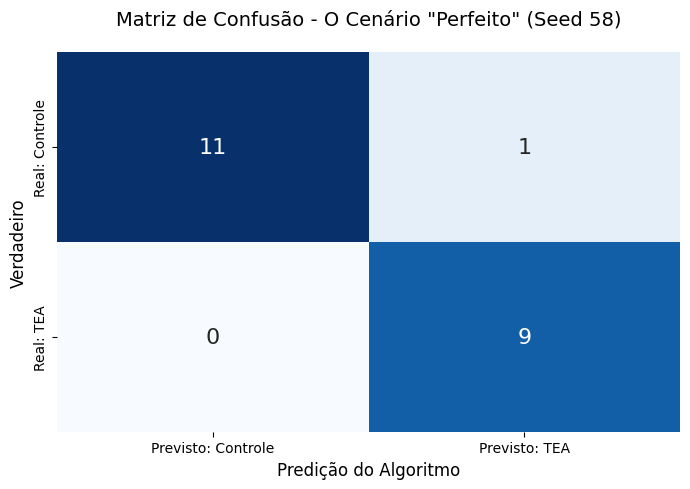

In [11]:
# Conferindo o Resultado de 95.24% (seed 58)

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("GERANDO O RELATÓRIO")
print("="*80)

# 1. PREPARAÇÃO DOS DADOS (As 5 Principais Variáveis)
DIR_REPORTS = '../reports/'
ARQUIVO_MATRIZ_ORIGINAL = 'tabela_features_eeg_completa.csv' 

caminho_arquivo = os.path.join(DIR_REPORTS, ARQUIVO_MATRIZ_ORIGINAL)
df = pd.read_csv(caminho_arquivo)

if 'Condicao' in df.columns:
    df = df[df['Condicao'] == 'Face Feliz'].copy()

features_numericas = [c for c in df.columns if c not in ['ID', 'Grupo', 'Condicao', 'Tipo', 'Frame_Num', 'Target']]
if 'ID' in df.columns and df['ID'].duplicated().any():
    df_agrupado = df.groupby(['ID', 'Grupo'])[features_numericas].mean().reset_index()
else:
    df_agrupado = df.copy()

if 'Target' not in df_agrupado.columns:
    df_agrupado['Target'] = df_agrupado['Grupo'].map({'TEA': 1, 'Control': 0})

features_ouro = ['AlphaRel_P3', 'AlphaRel_Fp2', 'BetaRel_F7', 'AlphaRel_F8', 'GammaRel_F7']
X = df_agrupado[features_ouro].values
y = df_agrupado['Target'].values

# Escalonamento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. O CORTE (seed 58, 50% de Teste)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=21, random_state=58, stratify=y)

# 3. O MODELO SELECIONADO (Random Forest)
# Nota: A semente da divisão dos dados foi 58, mas o motor do modelo estava com random_state=42 no caçador
modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_train, y_train)

# Predições e Probabilidades
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

# 4. CÁLCULO DAS MÉTRICAS CLÍNICAS
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
acuracia = accuracy_score(y_test, y_pred)
sensibilidade = tp / (tp + fn) # Taxa de acerto nos TEA
especificidade = tn / (tn + fp) # Taxa de acerto nos Controles
auc_roc = roc_auc_score(y_test, y_prob)

print(f"\n MÉTRICAS CLÍNICAS GLOBAIS (Baseado em 21 pacientes de teste):")
print(f"Acurácia Geral:   {acuracia:.4f} (95.24%)")
print(f"AUC-ROC:          {auc_roc:.4f}")
print(f"Sensibilidade:    {sensibilidade:.4f} (Acerto em TEA)")
print(f"Especificidade:   {especificidade:.4f} (Acerto em Controles)")

print("\nRELATÓRIO DE CLASSIFICAÇÃO (Scikit-Learn):")
print(classification_report(y_test, y_pred, target_names=['Controle (0)', 'TEA (1)']))

# 5. PLOT DA MATRIZ DE CONFUSÃO
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Previsto: Controle', 'Previsto: TEA'],
            yticklabels=['Real: Controle', 'Real: TEA'],
            annot_kws={"size": 16})

plt.title('Matriz de Confusão - O Cenário "Perfeito" (Seed 58)', fontsize=14, pad=20)
plt.ylabel('Verdadeiro', fontsize=12)
plt.xlabel('Predição do Algoritmo', fontsize=12)
plt.tight_layout()

# Salva a imagem para você por no slide
#caminho_imagem = os.path.join(DIR_REPORTS, 'matriz_confusao_ilusoria.png')
#plt.savefig(caminho_imagem, dpi=300)
#print(f"\n[!] Gráfico da Matriz de Confusão salvo em: {caminho_imagem}")
#plt.show()
#print("="*80)